In [2]:
import math
import matplotlib.pyplot as plt


In [3]:
# Normal Distribution
def normal_distribution(x, mu, sigma):
    return (1 / (sigma * math.sqrt(2 * math.pi))) * math.exp(-0.5 * ((x - mu) / sigma) ** 2)

In [4]:
# Plotting
x_values = [i * 0.1 for i in range(-100, 101)]  # x values from -10 to 10 with step 0.1

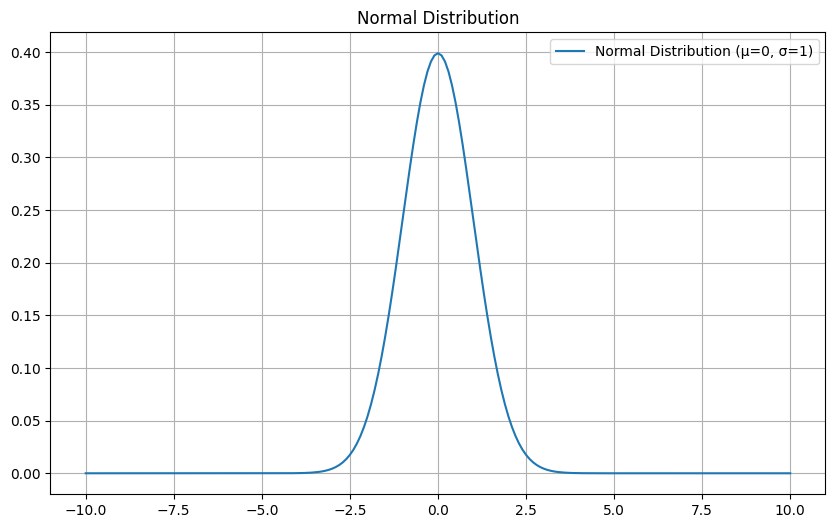

In [5]:
# Normal Distribution
plt.figure(figsize=(10, 6))
y_values = [normal_distribution(x, 0, 1) for x in x_values]
plt.plot(x_values, y_values, label="Normal Distribution (μ=0, σ=1)")
plt.title("Normal Distribution")
plt.legend()
plt.grid()
plt.show()

In [6]:
# Uniform Distribution
def uniform_distribution(x, a, b):
    if a <= x <= b:
        return 1 / (b - a)
    else:
        return 0

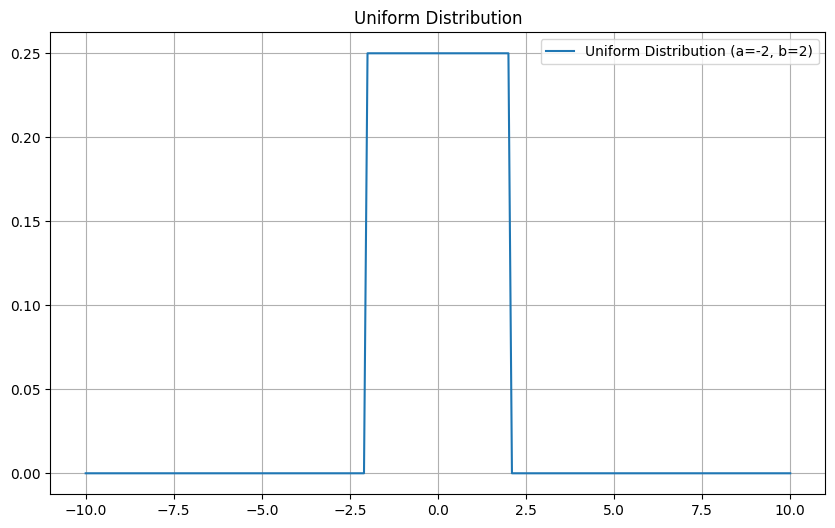

In [7]:
# Uniform Distribution
plt.figure(figsize=(10, 6))
y_values = [uniform_distribution(x, -2, 2) for x in x_values]
plt.plot(x_values, y_values, label="Uniform Distribution (a=-2, b=2)")
plt.title("Uniform Distribution")
plt.legend()
plt.grid()
plt.show()

In [8]:
# Exponential Distribution
def exponential_distribution(x, lam):
    if x >= 0:
        return lam * math.exp(-lam * x)
    else:
        return 0

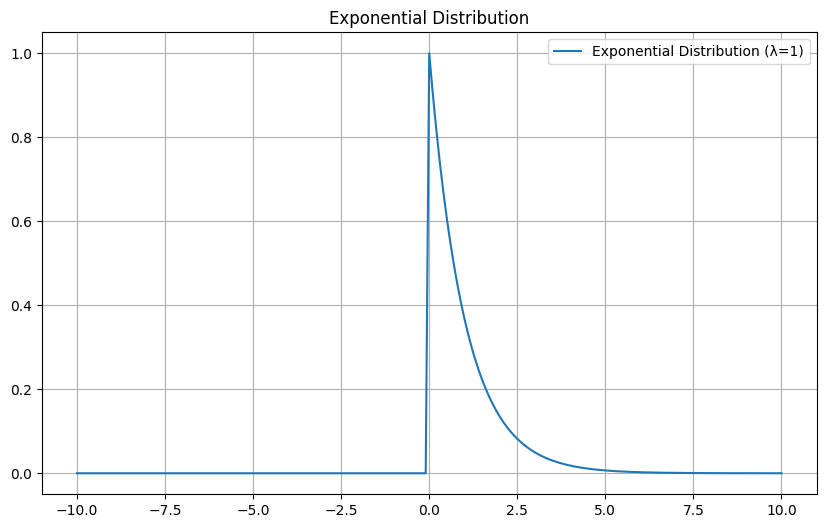

In [10]:
# Exponential Distribution
plt.figure(figsize=(10, 6))
y_values = [exponential_distribution(x, 1) for x in x_values]
plt.plot(x_values, y_values, label="Exponential Distribution (λ=1)")
plt.title("Exponential Distribution")
plt.legend()
plt.grid()
plt.show()

In [11]:
# Poisson Distribution
def poisson_distribution(k, lam):
    return (lam**k * math.exp(-lam)) / math.factorial(k)

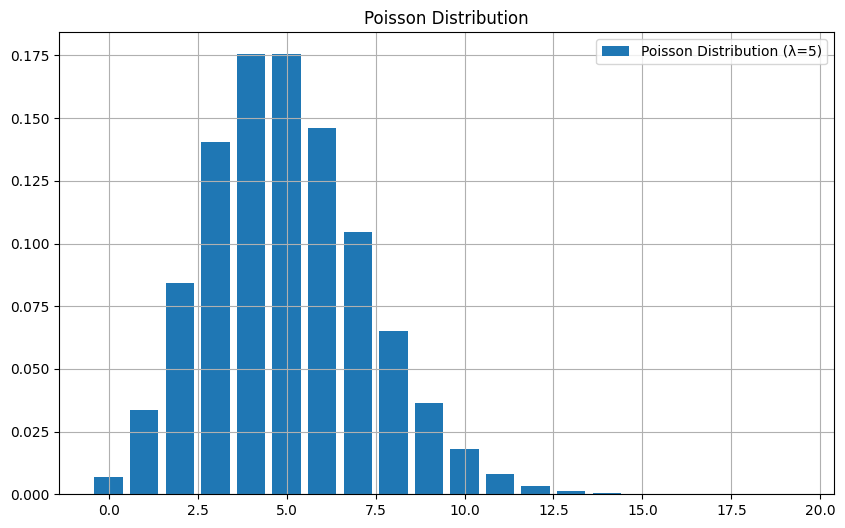

In [13]:
# Poisson Distribution
k_values = list(range(0, 20))
plt.figure(figsize=(10, 6))
y_values = [poisson_distribution(k, 5) for k in k_values]
plt.bar(k_values, y_values, label="Poisson Distribution (λ=5)")
plt.title("Poisson Distribution")
plt.legend()
plt.grid()
plt.show()

In [14]:
# Cauchy Distribution
def cauchy_distribution(x):
    return 1 / (math.pi * (1 + x**2))

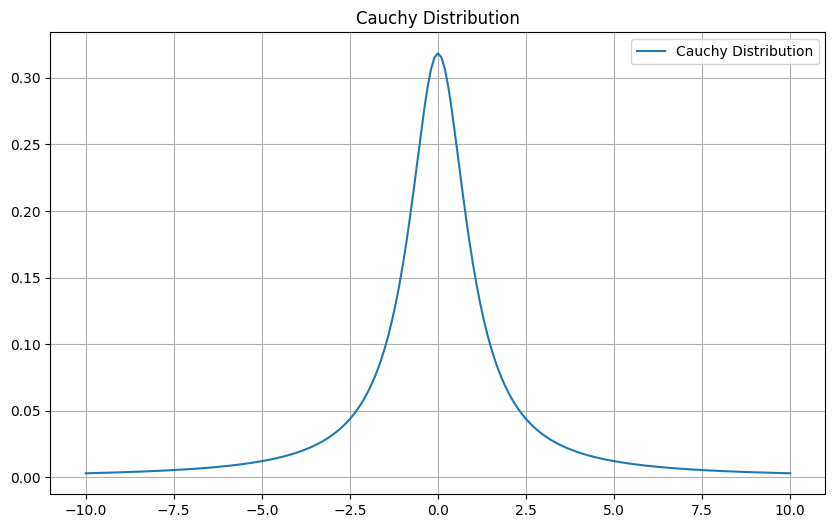

In [15]:
# Cauchy Distribution
plt.figure(figsize=(10, 6))
y_values = [cauchy_distribution(x) for x in x_values]
plt.plot(x_values, y_values, label="Cauchy Distribution")
plt.title("Cauchy Distribution")
plt.legend()
plt.grid()
plt.show()

In [16]:
# t-Distribution
def t_distribution(x, df):
    numerator = math.gamma((df + 1) / 2)
    denominator = math.sqrt(df * math.pi) * math.gamma(df / 2)
    return (numerator / denominator) * (1 + (x**2 / df)) ** (-(df + 1) / 2)

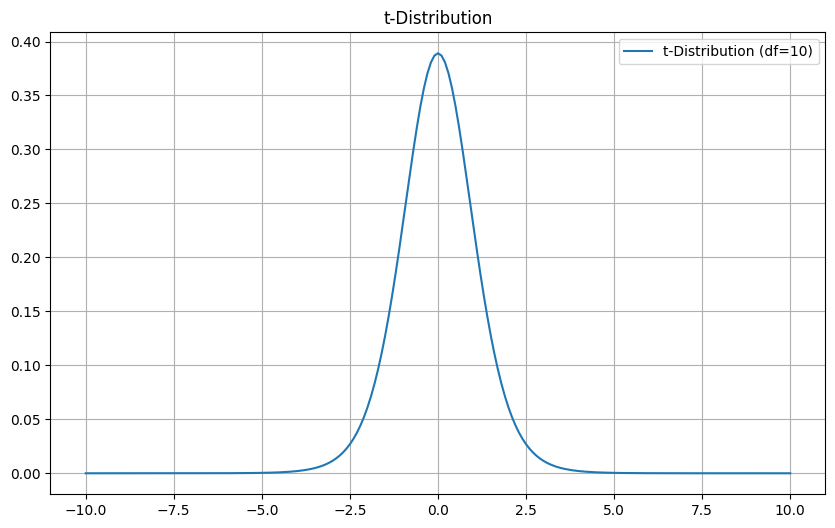

In [17]:
# t-Distribution
plt.figure(figsize=(10, 6))
y_values = [t_distribution(x, 10) for x in x_values]
plt.plot(x_values, y_values, label="t-Distribution (df=10)")
plt.title("t-Distribution")
plt.legend()
plt.grid()
plt.show()

In [18]:
# Chi-squared Distribution
def chi_squared_distribution(x, k):
    if x >= 0:
        numerator = x ** (k / 2 - 1) * math.exp(-x / 2)
        denominator = 2 ** (k / 2) * math.gamma(k / 2)
        return numerator / denominator
    else:
        return 0

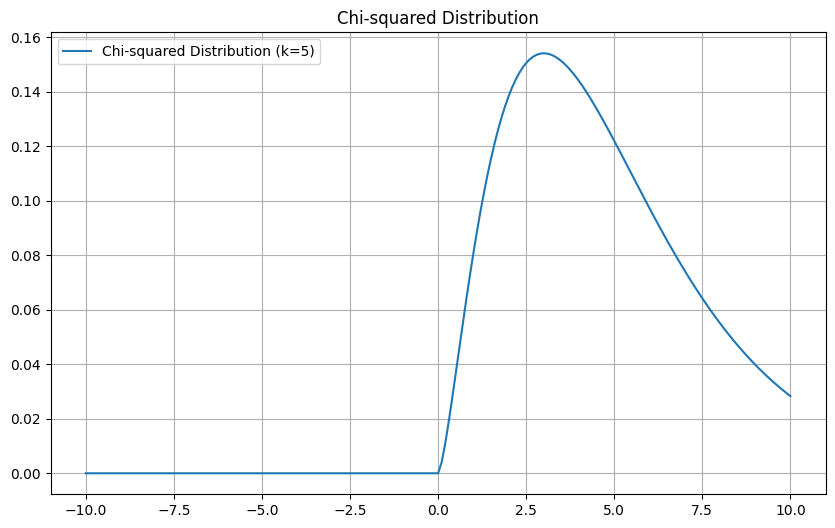

In [20]:
# Chi-squared Distribution
plt.figure(figsize=(10, 6))
y_values = [chi_squared_distribution(x, 5) for x in x_values]
plt.plot(x_values, y_values, label="Chi-squared Distribution (k=5)")
plt.title("Chi-squared Distribution")
plt.legend()
plt.grid()
plt.show()

In [30]:
# QUESTION 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report


In [24]:
# Load Iris dataset
def load_iris():
    df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data",
                     header=None, names=["sepal_length", "sepal_width", "petal_length", "petal_width", "class"])
    df["class"] = df["class"].astype("category").cat.codes 
    return df

In [25]:
# Gaussian probability
def gaussian_pdf(x, mean, var):
    return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-((x - mean) ** 2) / (2 * var))

In [26]:
# posterior probabilities
def predict(X_test, mean_var, class_probs):
    predictions = []
    for x in X_test:
        posteriors = {}
        for c, stats in mean_var.items():
            prior = np.log(class_probs[c])
            likelihood = np.sum(np.log(gaussian_pdf(x, stats["mean"], stats["var"])))
            posteriors[c] = prior + likelihood
        predictions.append(max(posteriors, key=posteriors.get))
    return np.array(predictions)

In [27]:
#  accuracy
def calculate_accuracy(y_test, y_pred):
    return np.mean(y_test == y_pred) * 100

In [28]:
# Naive Bayes classifier 
def run_bayesian_classifier(train_ratio):
    df = load_iris()
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    # Split 
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_ratio, random_state=42)

    # class priors
    classes, counts = np.unique(y_train, return_counts=True)
    class_probs = {c: counts[i] / len(y_train) for i, c in enumerate(classes)}

    #  mean and variance 
    mean_var = compute_mean_variance(X_train, y_train)

    # Predict 
    y_pred = predict(X_test, mean_var, class_probs)

    # accuracy and error rate
    accuracy = calculate_accuracy(y_test, y_pred)
    error_rate = 100 - accuracy

    return accuracy, error_rate

In [29]:
accuracy_70, error_70 = run_bayesian_classifier(0.7)
accuracy_80, error_80 = run_bayesian_classifier(0.8)

print(f"70:30 Split -> Accuracy: {accuracy_70:.2f}%, Error Rate: {error_70:.2f}%")
print(f"80:20 Split -> Accuracy: {accuracy_80:.2f}%, Error Rate: {error_80:.2f}%")


70:30 Split -> Accuracy: 97.78%, Error Rate: 2.22%
80:20 Split -> Accuracy: 100.00%, Error Rate: 0.00%


In [31]:
# Confusion Matrix 
def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=['Setosa', 'Versicolor', 'Virginica'], 
                yticklabels=['Setosa', 'Versicolor', 'Virginica'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
# Scatter Plot 
def scatter_predictions(y_test, y_pred):
    plt.figure(figsize=(6, 4))
    plt.scatter(range(len(y_test)), y_test, color="blue", label="Actual", alpha=0.6)
    plt.scatter(range(len(y_pred)), y_pred, color="red", marker='x', label="Predicted", alpha=0.6)
    plt.xlabel("Sample Index")
    plt.ylabel("Class Label")
    plt.title("Actual vs Predicted Class Labels")
    plt.legend()
    plt.show()

Results for 70:30 Split:
Accuracy: 97.78%, Error Rate: 2.22%

Classification Report:
               precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        19
  Versicolor       1.00      0.92      0.96        13
   Virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



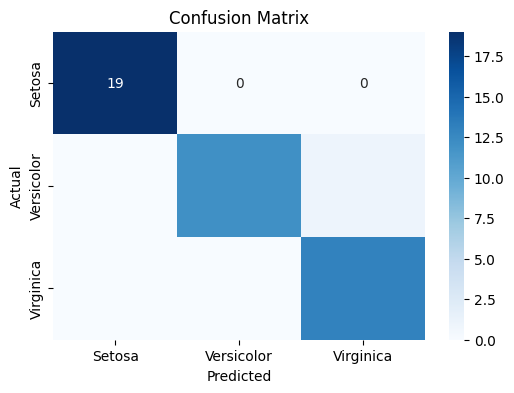

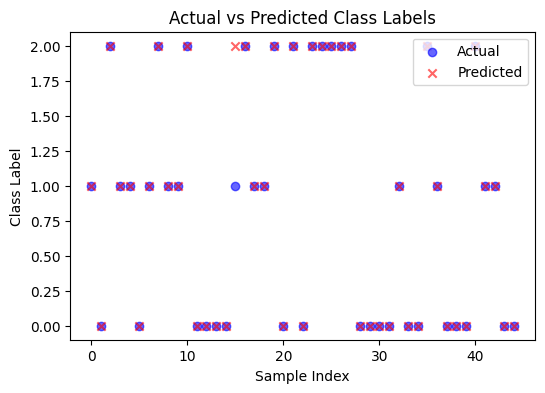


Results for 80:20 Split:
Accuracy: 100.00%, Error Rate: 0.00%

Classification Report:
               precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



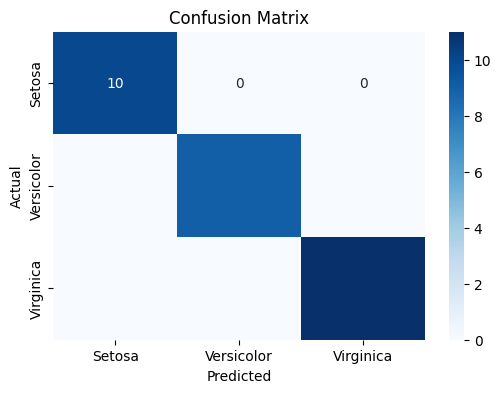

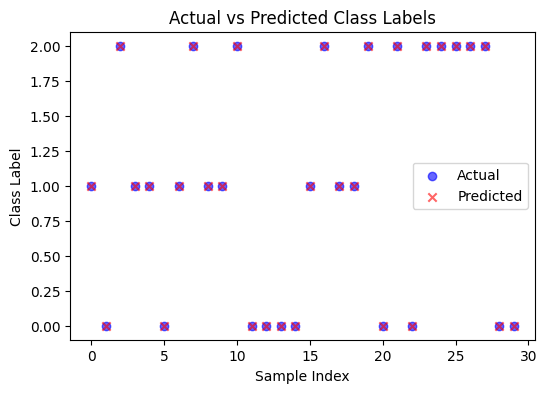

(100.0, 0.0)

In [ ]:
def run_bayesian_classifier(train_ratio):
    df = load_iris()
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_ratio, random_state=42)

    #class priors
    classes, counts = np.unique(y_train, return_counts=True)
    class_probs = {c: counts[i] / len(y_train) for i, c in enumerate(classes)}

    #mean and variance 
    mean_var = compute_mean_variance(X_train, y_train)

    # Predict
    y_pred = predict(X_test, mean_var, class_probs)

    #  accuracy and error rate
    accuracy = calculate_accuracy(y_test, y_pred)
    error_rate = 100 - accuracy

    #results
    print(f"Accuracy: {accuracy:.2f}%, Error Rate: {error_rate:.2f}%")
    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Setosa', 'Versicolor', 'Virginica']))

    # Plot
    plot_confusion_matrix(y_test, y_pred)
    scatter_predictions(y_test, y_pred)

    return accuracy, error_rate

print("Results for 70:30 Split:")
run_bayesian_classifier(0.7)

print("\nResults for 80:20 Split:")
run_bayesian_classifier(0.8)